In [133]:
import cv2 
import numpy as np
import matplotlib.pyplot as plt

In [134]:
def preprocess_image_gaussian(image):

    grayscale = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    blurr = cv2.GaussianBlur(grayscale, (7,7) , 0 )
    # try chanding the ksize
    
    return blurr


In [135]:
def preprocess_image_bilateral(image):

    blfilter = cv2.bilateralFilter(image,5,150,150)

    grayscale = cv2.cvtColor(blfilter, cv2.COLOR_BGR2GRAY)

    return grayscale

In [136]:
def detect_edges_sobel(image):

    sobelx = cv2.Sobel(image,cv2.CV_64F,1,0,ksize = 3)
    sobely = cv2.Sobel(image,cv2.CV_64F,1,0,ksize = 3)

    net = np.sqrt(sobelx**2 + sobely**2)

    net_norm  = np.uint8(255*(net)/np.max(net))

    return net_norm

In [137]:
def main():

    image = cv2.imread('animals.jpg')

    if image is None : 
        print("ERROR101")

    preprocessed_image = preprocess_image_gaussian(image)
    preprocessed_image2 = preprocess_image_bilateral(image)
    edges = detect_edges_sobel(preprocessed_image)
    edges2 = detect_edges_sobel(preprocessed_image2)
    edges3 = cv2.Canny(preprocessed_image, 50, 100)

    plt.figure(figsize=(30,15))

    plt.subplot(1,4,1)
    plt.imshow(cv2.cvtColor(image,cv2.COLOR_BGR2RGB))
    #Why this
    plt.title("OG")
    plt.axis('off')

    plt.subplot(1,4,2)
    plt.imshow(edges,cmap='gray')
    plt.title("Edges")
    plt.axis('off')

    plt.subplot(1,4,3)
    plt.imshow(edges2,cmap='gray')
    plt.title("biEdges")
    plt.axis('off')

    plt.subplot(1,4,4)
    plt.imshow(edges3,cmap='gray')
    plt.title("Cannyedges")
    plt.axis('off')

    

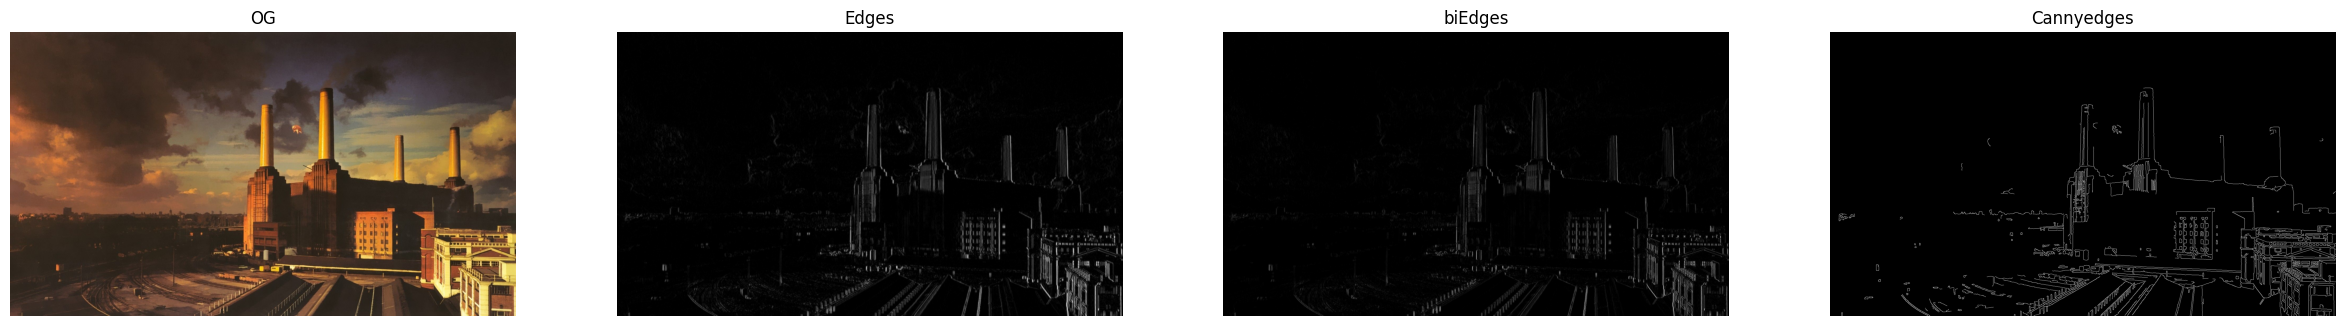

In [138]:
if __name__ == "__main__":
    main()